# Notebook 04 — Model Training

---

## Objective

Train and compare multiple machine learning models on the engineered features from Notebook 03 to find the best classifier for **fake job posting detection**.

## Models to be Trained

| # | Model | Type |
|---|-------|------|
| 1 | Logistic Regression | Linear |
| 2 | Multinomial Naive Bayes | Probabilistic |
| 3 | Linear SVM | Linear |
| 4 | Random Forest | Ensemble (Tree) |
| 5 | XGBoost | Ensemble (Boosting) |

## Why Compare Multiple Models?

- Different algorithms capture different patterns in the data.
- The dataset is **highly imbalanced** (~95% real, ~5% fake), so not every model handles this equally well.
- Comparing metrics like **F1-score** and **ROC-AUC** across models ensures we pick the one that best balances precision and recall.
- A **hybrid (voting) ensemble** of the best models can further boost performance.

In [14]:
# ==========================================================
# Part 2 — Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Optional — XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost loaded successfully!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed — skipping.")

# Plotting style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully!")

XGBoost loaded successfully!
All libraries imported successfully!


In [15]:
import pandas as pd
import numpy as np
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Optional — XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost loaded successfully!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed — skipping.")

# Plotting style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully!")

# ==========================================================
# Part 3 — Load Engineered Data
# ==========================================================

DATA_PATH = "/content/"

X_train = joblib.load(DATA_PATH + "X_train.pkl")
X_test  = joblib.load(DATA_PATH + "X_test.pkl")
y_train = joblib.load(DATA_PATH + "y_train.pkl")
y_test  = joblib.load(DATA_PATH + "y_test.pkl")

print("Data loaded successfully!")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

XGBoost loaded successfully!
All libraries imported successfully!
Data loaded successfully!

X_train shape : (14303, 5209)
X_test shape  : (3576, 5209)
y_train shape : (14303,)
y_test shape  : (3576,)


In [16]:
# ==========================================================
# Part 4 — Dataset Summary
# ==========================================================

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [X_train.shape[0], X_test.shape[0]],
    "Features": [X_train.shape[1], X_test.shape[1]]
})
display(summary)

print(f"\nNumber of Features: {X_train.shape[1]}")

print("\nClass Distribution (Training):")
train_dist = pd.Series(y_train).value_counts().sort_index()
train_dist.index = ["Real Job (0)", "Fake Job (1)"]
print(train_dist)
print(f"\nFake Job Ratio: {train_dist.iloc[1] / train_dist.sum() * 100:.2f}%")

print("\nClass Distribution (Testing):")
test_dist = pd.Series(y_test).value_counts().sort_index()
test_dist.index = ["Real Job (0)", "Fake Job (1)"]
print(test_dist)
print(f"\nFake Job Ratio: {test_dist.iloc[1] / test_dist.sum() * 100:.2f}%")

Dataset Summary


,Dataset,Samples,Features
0,Training,14303,5209
1,Testing,3576,5209



Number of Features: 5209

Class Distribution (Training):
Real Job (0)    13611
Fake Job (1)      692
Name: count, dtype: int64

Fake Job Ratio: 4.84%

Class Distribution (Testing):
Real Job (0)    3403
Fake Job (1)     173
Name: count, dtype: int64

Fake Job Ratio: 4.84%


---
## Part 5 — Train Individual Models

We train each model, record its training time, and store it for later evaluation.

In [17]:
# ==========================================================
# Part 5 — Train Individual Models
# ==========================================================

trained_models = {}
training_times = {}

# --- 1. Logistic Regression ---
print("Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
training_times["Logistic Regression"] = time.time() - start
trained_models["Logistic Regression"] = lr
print(f"  Done in {training_times['Logistic Regression']:.2f}s")

# --- 2. Multinomial Naive Bayes ---
print("\nTraining Multinomial Naive Bayes...")
start = time.time()
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
training_times["Multinomial NB"] = time.time() - start
trained_models["Multinomial NB"] = nb
print(f"  Done in {training_times['Multinomial NB']:.2f}s")

# --- 3. Linear SVM ---
print("\nTraining Linear SVM...")
start = time.time()
svm = LinearSVC(max_iter=2000, random_state=42, class_weight="balanced")
svm.fit(X_train, y_train)
training_times["Linear SVM"] = time.time() - start
trained_models["Linear SVM"] = svm
print(f"  Done in {training_times['Linear SVM']:.2f}s")

# --- 4. Random Forest ---
print("\nTraining Random Forest...")
start = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)
training_times["Random Forest"] = time.time() - start
trained_models["Random Forest"] = rf
print(f"  Done in {training_times['Random Forest']:.2f}s")

# --- 5. XGBoost (Optional) ---
if XGBOOST_AVAILABLE:
    print("\nTraining XGBoost...")
    # Calculate scale_pos_weight for imbalanced dataset
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos = n_neg / n_pos

    start = time.time()
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    training_times["XGBoost"] = time.time() - start
    trained_models["XGBoost"] = xgb
    print(f"  Done in {training_times['XGBoost']:.2f}s")

print("\n" + "=" * 60)
print(f"All {len(trained_models)} models trained successfully!")
print("=" * 60)

Training Logistic Regression...
  Done in 27.25s

Training Multinomial Naive Bayes...
  Done in 0.04s

Training Linear SVM...
  Done in 2.72s

Training Random Forest...
  Done in 32.15s

Training XGBoost...
  Done in 149.40s

All 5 models trained successfully!


---
## Part 6 — Evaluate Every Model

For each model we compute: Accuracy, Precision, Recall, F1, ROC-AUC, along with the Classification Report and Confusion Matrix.

Evaluation: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.93      0.96      3403
        Fake       0.41      0.92      0.57       173

    accuracy                           0.93      3576
   macro avg       0.70      0.93      0.77      3576
weighted avg       0.97      0.93      0.94      3576



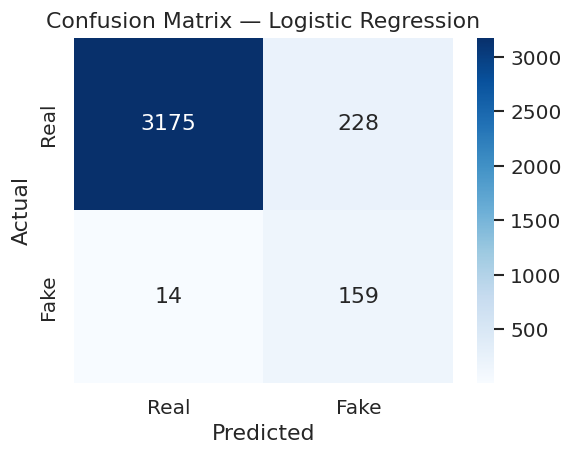


Evaluation: Multinomial NB

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.94      0.96      3403
        Fake       0.34      0.57      0.43       173

    accuracy                           0.93      3576
   macro avg       0.66      0.76      0.70      3576
weighted avg       0.95      0.93      0.94      3576



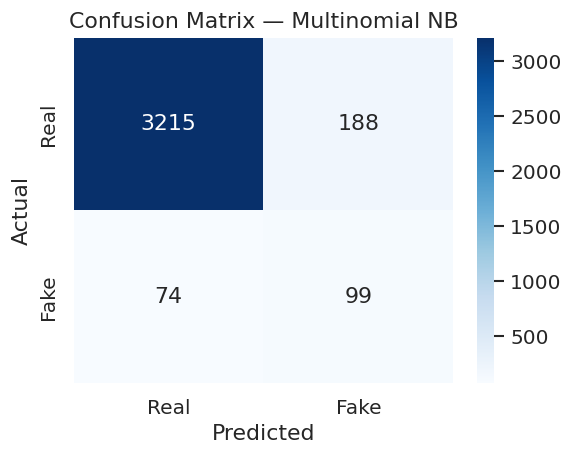


Evaluation: Linear SVM

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
        Fake       0.79      0.88      0.83       173

    accuracy                           0.98      3576
   macro avg       0.89      0.93      0.91      3576
weighted avg       0.98      0.98      0.98      3576



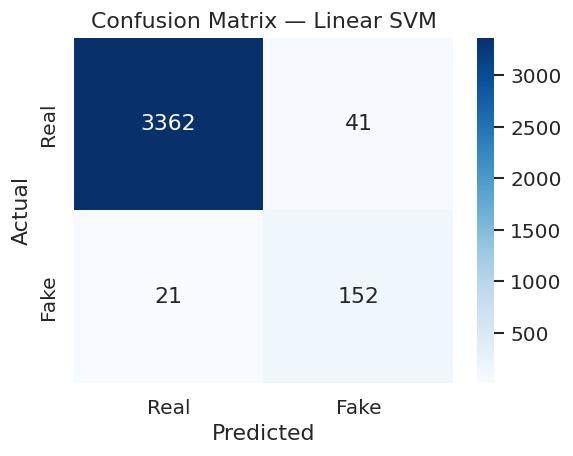


Evaluation: Random Forest

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      3403
        Fake       0.99      0.60      0.74       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



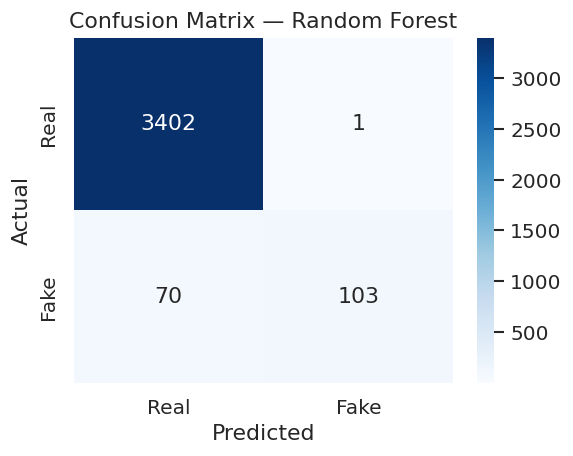


Evaluation: XGBoost

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
        Fake       0.81      0.86      0.83       173

    accuracy                           0.98      3576
   macro avg       0.90      0.93      0.91      3576
weighted avg       0.98      0.98      0.98      3576



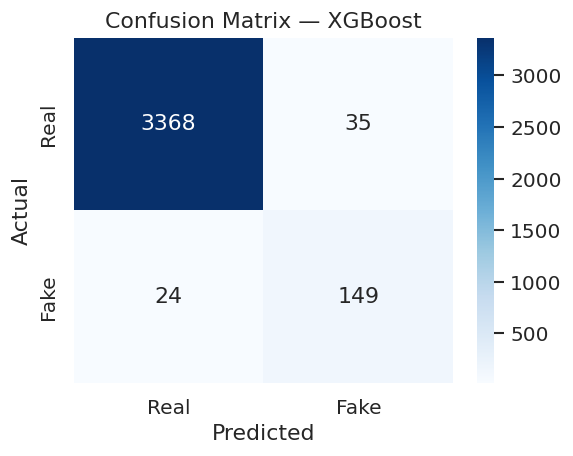

In [18]:
# ==========================================================
# Part 6 — Evaluate Every Model
# ==========================================================

results = []
predictions = {}

for name, model in trained_models.items():
    print("=" * 60)
    print(f"Evaluation: {name}")
    print("=" * 60)

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Compute ROC-AUC
    # LinearSVC has no predict_proba — use decision_function
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred.astype(float)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4),
        "Training Time (s)": round(training_times[name], 2)
    })

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Real", "Fake"],
                yticklabels=["Real", "Fake"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()
    print()

In [19]:
# ==========================================================
# Part 7 — Compare Models
# ==========================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("=" * 60)
print("Model Comparison (sorted by F1-Score)")
print("=" * 60)
print("Note: Sorted by F1-Score because the dataset is imbalanced.")
print()

display(results_df)

Model Comparison (sorted by F1-Score)
Note: Sorted by F1-Score because the dataset is imbalanced.



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,XGBoost,0.9835,0.8098,0.8613,0.8347,0.9931,149.40
1,Linear SVM,0.9827,0.7876,0.8786,0.8306,0.9924,2.72
2,Random Forest,0.9801,0.9904,0.5954,0.7437,0.9940,32.15
3,Logistic Regression,0.9323,0.4109,0.9191,0.5679,0.9780,27.25
4,Multinomial NB,0.9267,0.3449,0.5723,0.4304,0.8174,0.04


---
## Part 8 — Visualizations

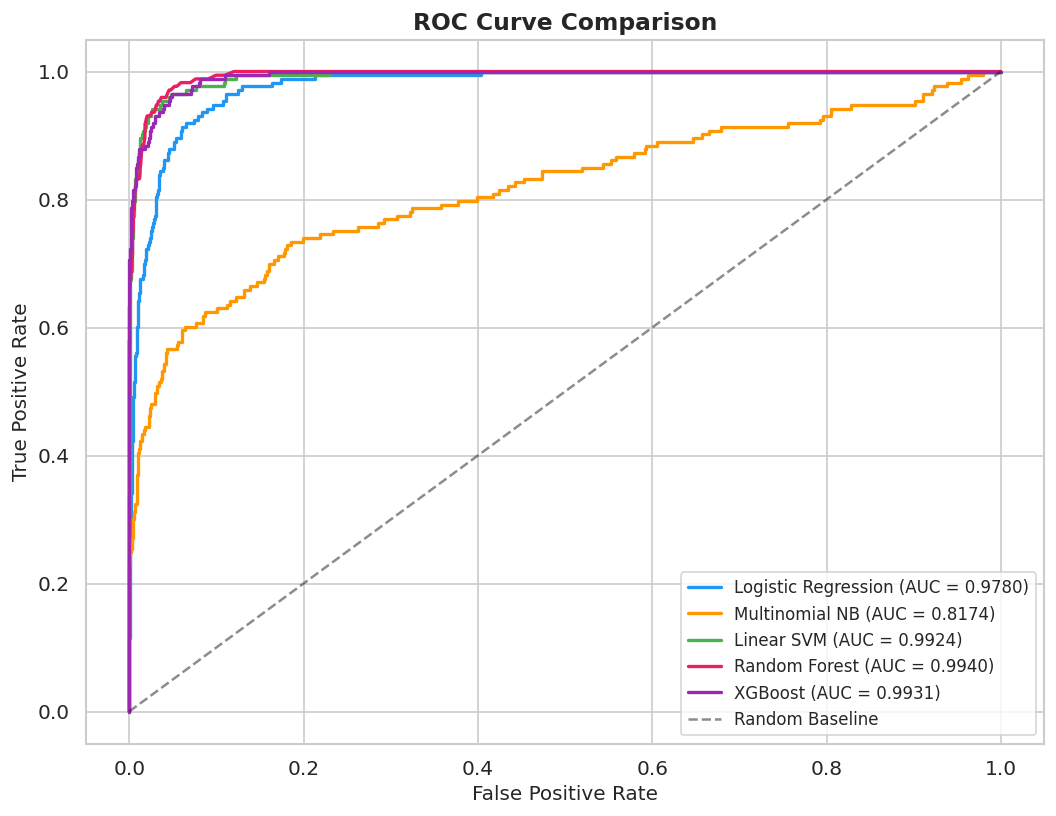

Saved: results/figures/roc_curve.png


In [22]:
import os

# ==========================================================
# Part 8a — ROC Curve Comparison
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

for i, (name, model) in enumerate(trained_models.items()):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[i % len(colors)],
            label=f"{name} (AUC = {auc_val:.4f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random Baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs("../results/figures", exist_ok=True)

plt.savefig("../results/figures/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/roc_curve.png")

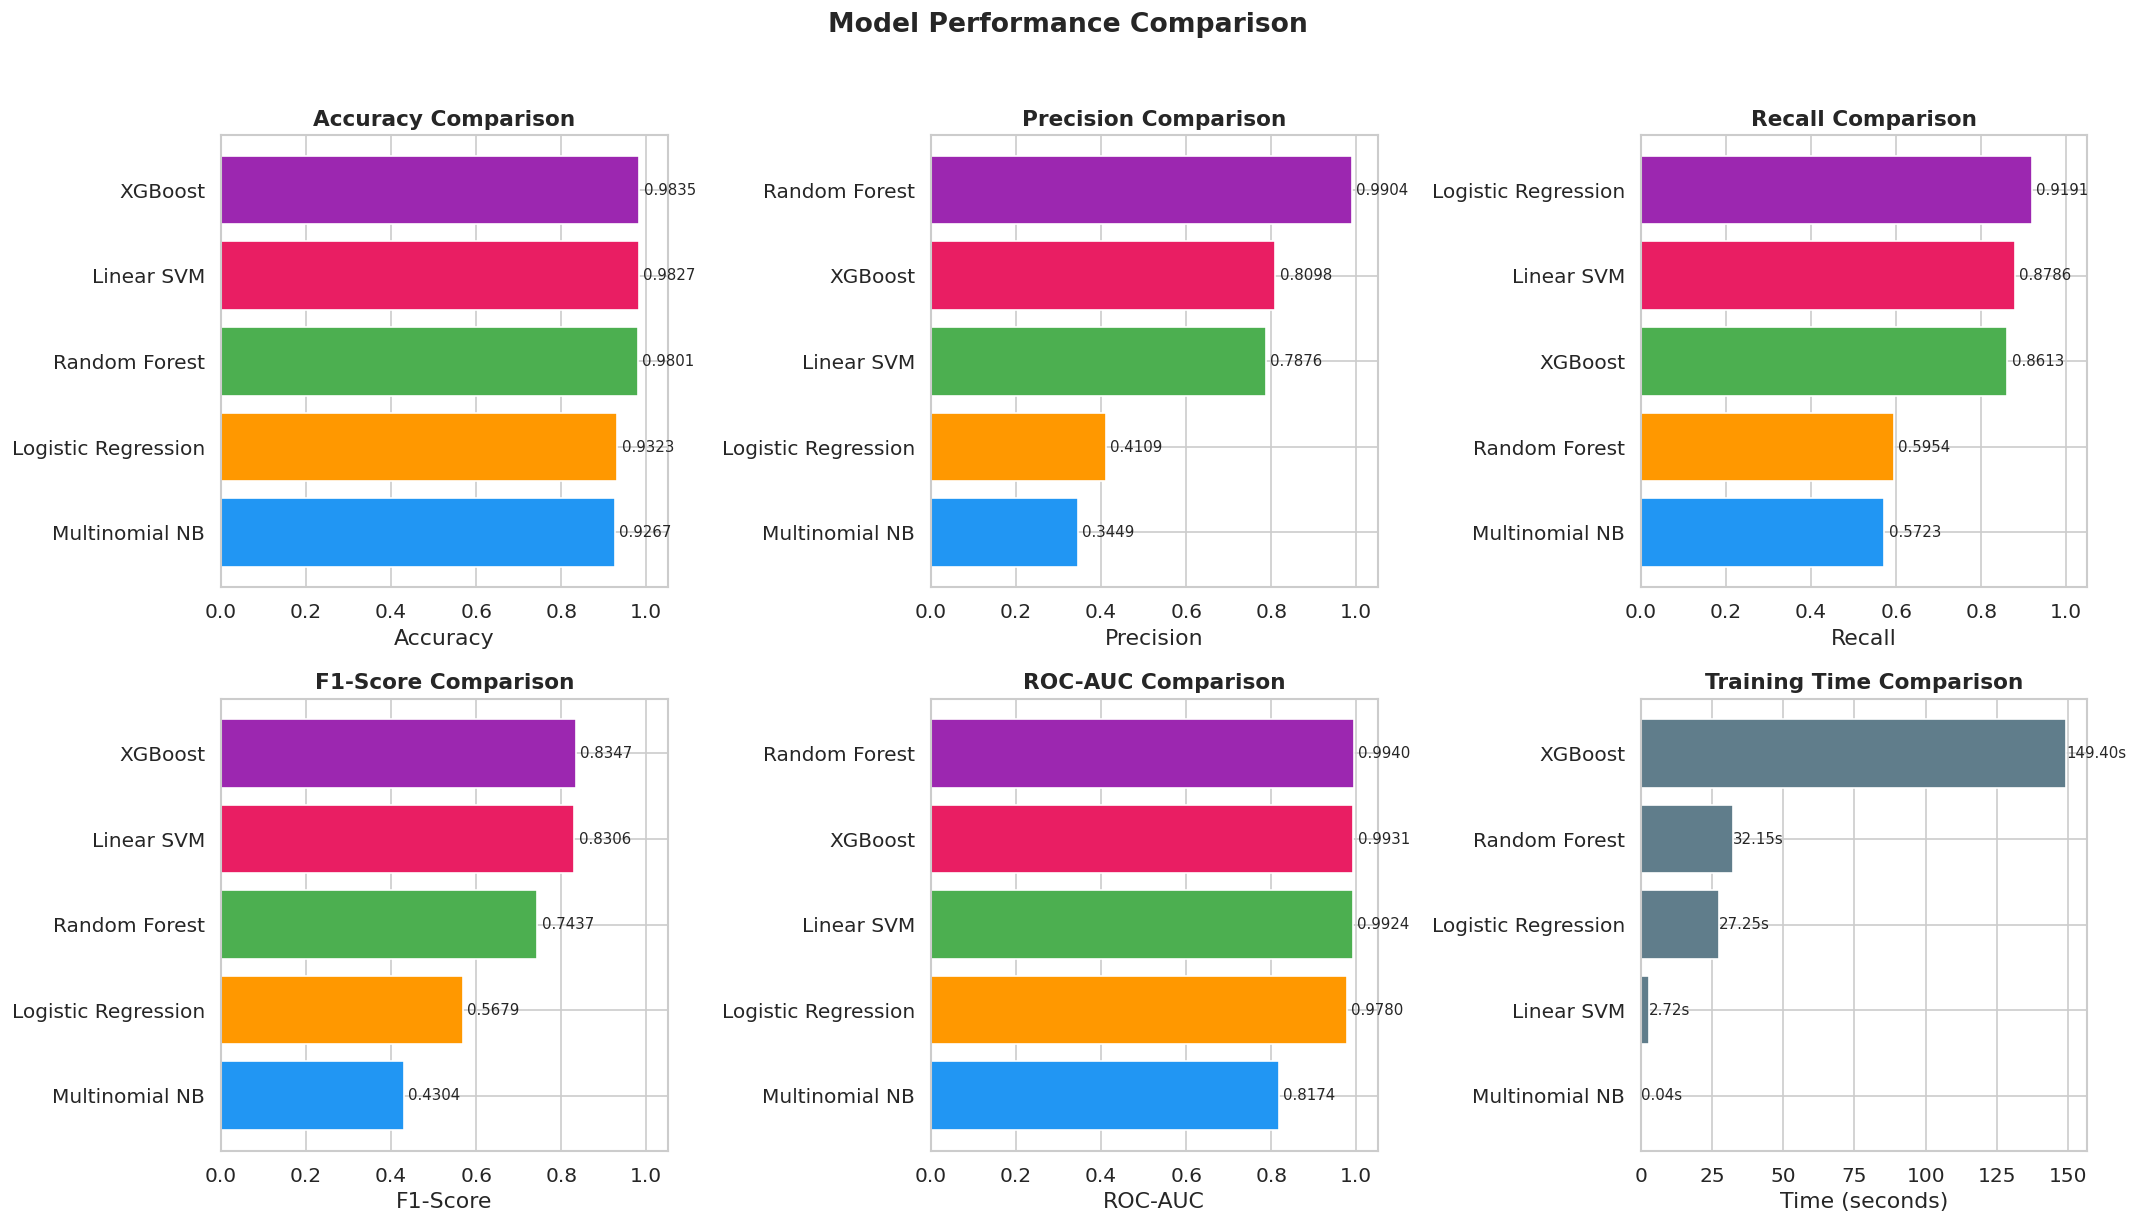

Saved: results/figures/model_comparison.png


In [23]:
# ==========================================================
# Part 8b — Metric Comparison Bar Charts
# ==========================================================

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
bar_colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = results_df.sort_values(by=metric, ascending=True)
    bars = ax.barh(data["Model"], data[metric],
                   color=bar_colors[:len(data)], edgecolor="white")
    ax.set_xlim(0, 1.05)
    ax.set_title(f"{metric} Comparison", fontsize=13, fontweight="bold")
    ax.set_xlabel(metric)

    # Annotate bars
    for bar, val in zip(bars, data[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

# Training Time comparison in the last subplot
ax = axes[5]
data = results_df.sort_values(by="Training Time (s)", ascending=True)
bars = ax.barh(data["Model"], data["Training Time (s)"],
               color="#607D8B", edgecolor="white")
ax.set_title("Training Time Comparison", fontsize=13, fontweight="bold")
ax.set_xlabel("Time (seconds)")
for bar, val in zip(bars, data["Training Time (s)"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}s", va="center", fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/model_comparison.png")

---
## Part 9 — Build Hybrid Model

Take the best two individual models and combine them into a **VotingClassifier** for potentially improved performance.

Top 2 models by F1-Score: ['XGBoost', 'Linear SVM']
Voting type: hard

Training VotingClassifier...
  Done in 154.54s

Hybrid Model Results
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      3403
        Fake       0.94      0.80      0.87       173

    accuracy                           0.99      3576
   macro avg       0.96      0.90      0.93      3576
weighted avg       0.99      0.99      0.99      3576



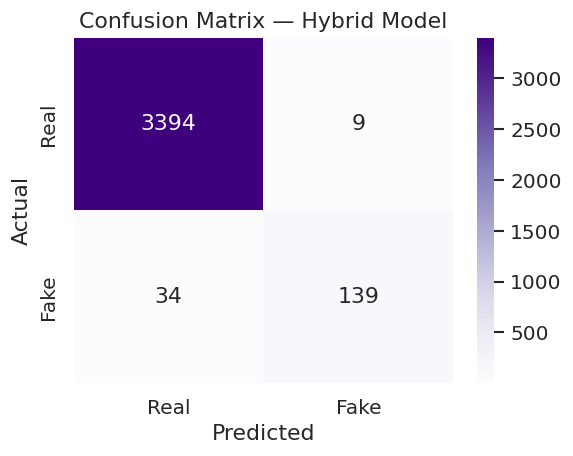


Updated Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Hybrid (XGBoost + Linear SVM),0.9880,0.9392,0.8035,0.8660,0.9004,154.54
1,XGBoost,0.9835,0.8098,0.8613,0.8347,0.9931,149.40
2,Linear SVM,0.9827,0.7876,0.8786,0.8306,0.9924,2.72
3,Random Forest,0.9801,0.9904,0.5954,0.7437,0.9940,32.15
4,Logistic Regression,0.9323,0.4109,0.9191,0.5679,0.9780,27.25
5,Multinomial NB,0.9267,0.3449,0.5723,0.4304,0.8174,0.04


In [24]:
# ==========================================================
# Part 9 — Build Hybrid Model (VotingClassifier)
# ==========================================================

# Pick the top 2 models by F1-Score
top2 = results_df.head(2)["Model"].tolist()
print(f"Top 2 models by F1-Score: {top2}")

# Build estimator list for VotingClassifier
# LinearSVC doesn't support predict_proba → use 'hard' voting
estimators = [(name, trained_models[name]) for name in top2]

# Check if all top models support predict_proba for soft voting
all_have_proba = all(hasattr(trained_models[n], "predict_proba") for n in top2)
voting_type = "soft" if all_have_proba else "hard"
print(f"Voting type: {voting_type}")

voting_clf = VotingClassifier(
    estimators=estimators,
    voting=voting_type,
    n_jobs=-1
)

print("\nTraining VotingClassifier...")
start = time.time()
voting_clf.fit(X_train, y_train)
voting_time = time.time() - start
print(f"  Done in {voting_time:.2f}s")

# Evaluate
y_pred_hybrid = voting_clf.predict(X_test)

if voting_type == "soft":
    y_prob_hybrid = voting_clf.predict_proba(X_test)[:, 1]
    auc_hybrid = roc_auc_score(y_test, y_prob_hybrid)
else:
    auc_hybrid = roc_auc_score(y_test, y_pred_hybrid)

hybrid_metrics = {
    "Model": f"Hybrid ({' + '.join(top2)})",
    "Accuracy": round(accuracy_score(y_test, y_pred_hybrid), 4),
    "Precision": round(precision_score(y_test, y_pred_hybrid), 4),
    "Recall": round(recall_score(y_test, y_pred_hybrid), 4),
    "F1-Score": round(f1_score(y_test, y_pred_hybrid), 4),
    "ROC-AUC": round(auc_hybrid, 4),
    "Training Time (s)": round(voting_time, 2)
}

# Add to results
results_df = pd.concat([results_df, pd.DataFrame([hybrid_metrics])], ignore_index=True)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

trained_models[hybrid_metrics["Model"]] = voting_clf
predictions[hybrid_metrics["Model"]] = y_pred_hybrid

print("\n" + "=" * 60)
print("Hybrid Model Results")
print("=" * 60)
print(classification_report(y_test, y_pred_hybrid, target_names=["Real", "Fake"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_hybrid)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — Hybrid Model")
plt.tight_layout()
plt.show()

print("\nUpdated Comparison Table:")
display(results_df)

---
## Part 10 — Feature Importance

Display the **Top 20 most important features** from tree-based models (Random Forest / XGBoost).

Could not load feature names — using generic names.

Top 20 Features by Random Forest:


,Feature,Importance
0,feature_5206,0.034875
1,feature_5202,0.027785
2,feature_5198,0.009467
3,feature_4353,0.009461
4,feature_1978,0.008790
5,feature_5199,0.008752
6,feature_4035,0.008162
7,feature_3272,0.006194
8,feature_4782,0.006155
9,feature_3135,0.006083


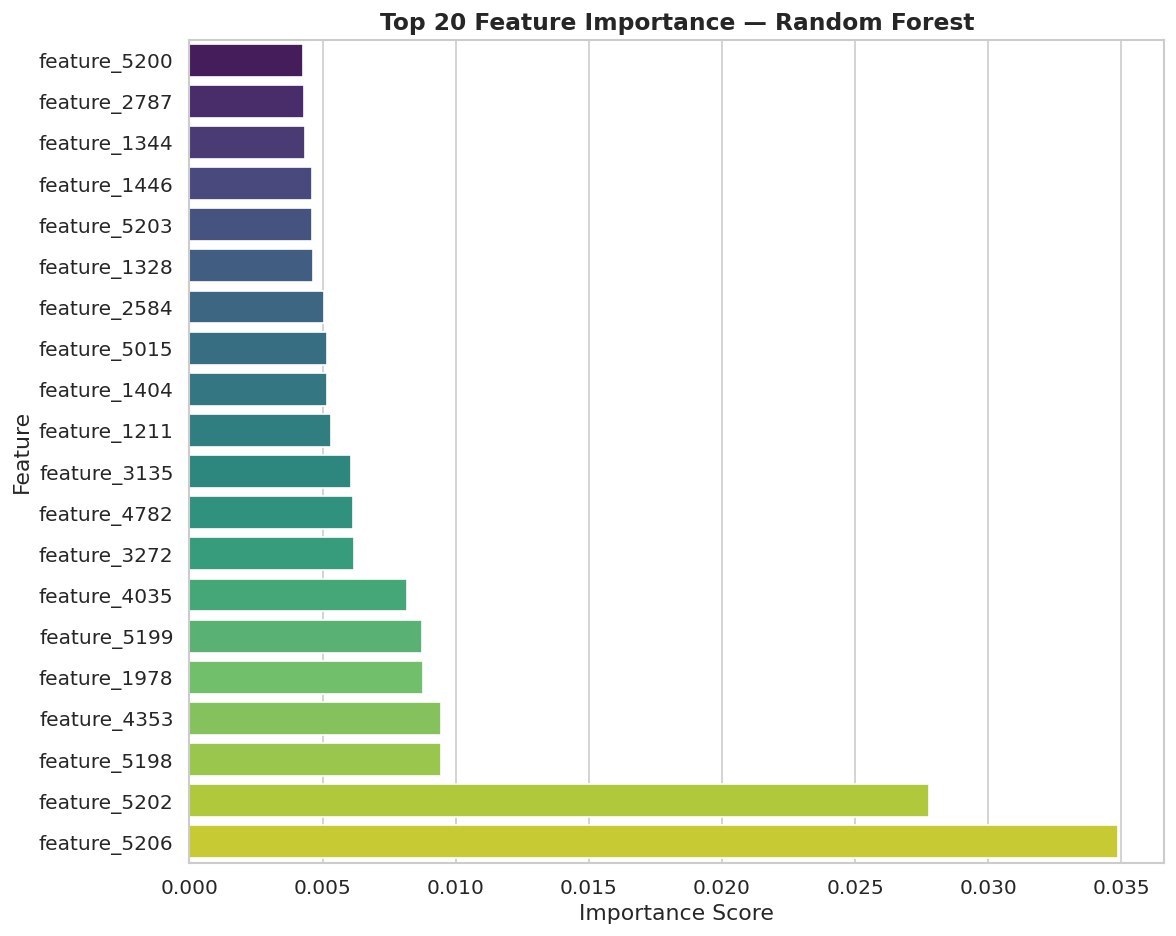

Saved: results/figures/feature_importance.png


In [25]:
# ==========================================================
# Part 10 — Feature Importance
# ==========================================================

# Try to load the TF-IDF vectorizer and encoder for feature names
try:
    tfidf = joblib.load(DATA_PATH + "tfidf_vectorizer.pkl")
    encoder = joblib.load(DATA_PATH + "onehot_encoder.pkl")

    tfidf_names = tfidf.get_feature_names_out().tolist()
    encoder_names = encoder.get_feature_names_out().tolist()
    numerical_names = [
        "text_length", "word_count", "avg_word_length",
        "telecommuting", "has_company_logo", "has_questions",
        "salary_range_missing", "department_missing",
        "company_profile_missing", "requirements_missing", "benefits_missing"
    ]
    all_feature_names = tfidf_names + encoder_names + numerical_names
    print(f"Total feature names reconstructed: {len(all_feature_names)}")
except:
    all_feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
    print("Could not load feature names — using generic names.")

# Use Random Forest or XGBoost for feature importance
if "Random Forest" in trained_models:
    importance_model = trained_models["Random Forest"]
    importance_name = "Random Forest"
elif XGBOOST_AVAILABLE and "XGBoost" in trained_models:
    importance_model = trained_models["XGBoost"]
    importance_name = "XGBoost"
else:
    importance_model = None
    importance_name = None

if importance_model is not None:
    importances = importance_model.feature_importances_

    # Handle case where feature names don't match
    n_features = len(importances)
    if len(all_feature_names) >= n_features:
        feat_names = all_feature_names[:n_features]
    else:
        feat_names = all_feature_names + [f"feature_{i}" for i in range(len(all_feature_names), n_features)]

    feat_imp = pd.DataFrame({
        "Feature": feat_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    top_20 = feat_imp.head(20)

    print(f"\nTop 20 Features by {importance_name}:")
    display(top_20.reset_index(drop=True))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(
        data=top_20.iloc[::-1],
        x="Importance", y="Feature",
        palette="viridis", ax=ax
    )
    ax.set_title(f"Top 20 Feature Importance — {importance_name}",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Importance Score")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig("../results/figures/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/figures/feature_importance.png")
else:
    print("No tree-based model available for feature importance.")

In [26]:
# ==========================================================
# Part 11 — Select Best Model
# ==========================================================

best_row = results_df.loc[results_df["F1-Score"].idxmax()]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

print("=" * 60)
print("Best Model Selected (by F1-Score)")
print("=" * 60)
print(f"\n  Model    : {best_model_name}")
print(f"  F1-Score : {best_row['F1-Score']}")
print(f"  Accuracy : {best_row['Accuracy']}")
print(f"  ROC-AUC  : {best_row['ROC-AUC']}")

Best Model Selected (by F1-Score)

  Model    : Hybrid (XGBoost + Linear SVM)
  F1-Score : 0.866
  Accuracy : 0.988
  ROC-AUC  : 0.9004


In [27]:
# ==========================================================
# Part 12 — Save Models
# ==========================================================

import os
os.makedirs("../models", exist_ok=True)

# Save best model
joblib.dump(best_model, "../models/best_model.pkl")
print(f"Saved: models/best_model.pkl  ({best_model_name})")

# Save all trained models
joblib.dump(trained_models, "../models/all_models.pkl")
print(f"Saved: models/all_models.pkl  ({len(trained_models)} models)")

Saved: models/best_model.pkl  (Hybrid (XGBoost + Linear SVM))
Saved: models/all_models.pkl  (6 models)


Saved: results/model_comparison.csv


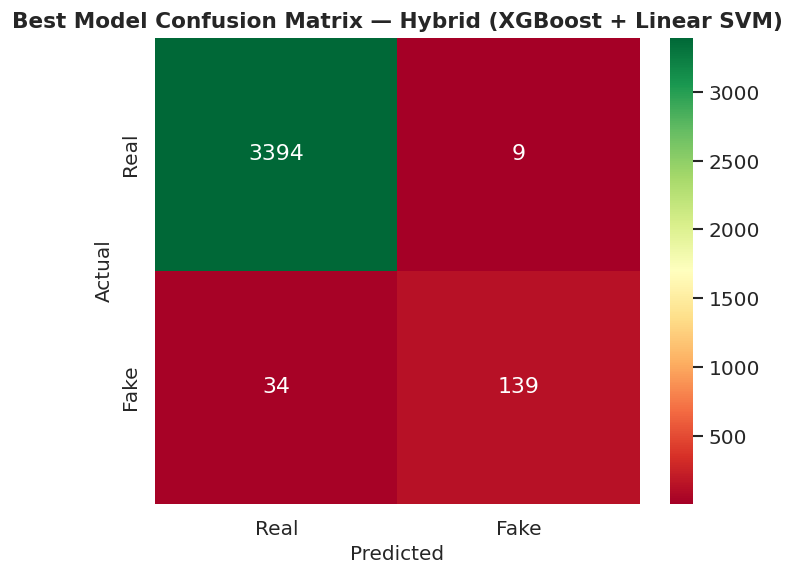

Saved: results/figures/confusion_matrix.png

All Results Saved Successfully!


,File,Location
0,model_comparison.csv,results/
1,confusion_matrix.png,results/figures/
2,roc_curve.png,results/figures/
3,feature_importance.png,results/figures/
4,model_comparison.png,results/figures/
5,best_model.pkl,models/
6,all_models.pkl,models/


In [28]:
# ==========================================================
# Part 13 — Save Results
# ==========================================================

# Save comparison CSV
results_df.to_csv("../results/model_comparison.csv", index=False)
print("Saved: results/model_comparison.csv")

# Save best model confusion matrix as separate figure
y_pred_best = trained_models[best_model_name].predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="RdYlGn",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Best Model Confusion Matrix — {best_model_name}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/confusion_matrix.png")

print("\n" + "=" * 60)
print("All Results Saved Successfully!")
print("=" * 60)

saved_summary = pd.DataFrame({
    "File": [
        "model_comparison.csv",
        "confusion_matrix.png",
        "roc_curve.png",
        "feature_importance.png",
        "model_comparison.png",
        "best_model.pkl",
        "all_models.pkl"
    ],
    "Location": [
        "results/",
        "results/figures/",
        "results/figures/",
        "results/figures/",
        "results/figures/",
        "models/",
        "models/"
    ]
})
display(saved_summary)

---
## Part 14 — Notebook Summary

### Results

In [29]:
# ==========================================================
# Part 14 — Notebook Summary
# ==========================================================

print("=" * 60)
print("NOTEBOOK 04 — MODEL TRAINING SUMMARY")
print("=" * 60)

print(f"\n  Models Trained       : {len(trained_models)}")
print(f"  Best Model           : {best_model_name}")
print(f"  Best F1-Score        : {best_row['F1-Score']}")
print(f"  Best Accuracy        : {best_row['Accuracy']}")
print(f"  Best ROC-AUC         : {best_row['ROC-AUC']}")
print(f"\n  Selection Criteria   : Highest F1-Score")
print(f"  Reason               : Dataset is imbalanced (~95% Real, ~5% Fake).")
print(f"                         F1-Score balances Precision and Recall,")
print(f"                         making it the most appropriate metric.")

print("\n" + "=" * 60)
print("Final Comparison Table")
print("=" * 60)
display(results_df)

print("\n✅ Notebook 04 completed. Proceed to Notebook 05 for detailed evaluation.")

NOTEBOOK 04 — MODEL TRAINING SUMMARY

  Models Trained       : 6
  Best Model           : Hybrid (XGBoost + Linear SVM)
  Best F1-Score        : 0.866
  Best Accuracy        : 0.988
  Best ROC-AUC         : 0.9004

  Selection Criteria   : Highest F1-Score
  Reason               : Dataset is imbalanced (~95% Real, ~5% Fake).
                         F1-Score balances Precision and Recall,
                         making it the most appropriate metric.

Final Comparison Table


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Hybrid (XGBoost + Linear SVM),0.9880,0.9392,0.8035,0.8660,0.9004,154.54
1,XGBoost,0.9835,0.8098,0.8613,0.8347,0.9931,149.40
2,Linear SVM,0.9827,0.7876,0.8786,0.8306,0.9924,2.72
3,Random Forest,0.9801,0.9904,0.5954,0.7437,0.9940,32.15
4,Logistic Regression,0.9323,0.4109,0.9191,0.5679,0.9780,27.25
5,Multinomial NB,0.9267,0.3449,0.5723,0.4304,0.8174,0.04



✅ Notebook 04 completed. Proceed to Notebook 05 for detailed evaluation.
